<a href="https://colab.research.google.com/github/Linford24/AfricaBp_Computer_Vision_for_Biodiversity_Classification/blob/main/biodiversity_prediction_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Lambda, Dropout, GlobalAveragePooling2D
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split

import io
import zipfile
import requests
from PIL import Image
import ee
import geemap
import rasterio


In [ ]:
ee.Authenticate()
ee.Initialize(project="africabp")

MessageError: Error: credential propagation was unsuccessful

### What is Remote Sensing

Remote Sensing is a form of acquiring information from an object or location without
making physical contact.
Mostly, remote sensing is employed in observing the Earth and other planets.
It enables capturing widely global land masses, vegetation, weather patterns to very fine detailed minerals
in the land.
In Biodiversity Conservation, remote sensing is employed largely in phenology, which involves
the study of periodic events in biological life cycles and how these are influenced
by seasonal and interannual variations in climate, habitat factors (such as elevation), human activities and many more.


### How Does Remote Sensing Work
The electromagnetic spectrum is made up of a number of bands/waves with different wavelengths.
The well known bands are indicated below
   - Gamma -> X-rays -> UltraViolet(UV) -> visible light(Violet,Indigo,blue,Green,Blue,Red) -> Infrared -> Microwave -> Radiowave.
- Each band has its wavelength.
Humans can basically see in the visible light range of the electromagnetic spectrum, with wavelegth range of 400 nanometers to 700 nanometers.
The things we see are formed from combinations of the Red, Green and Blue (RGB) Bands of the
visible light spectrum. As the light reaches the eye, it is processed to extract the RGB bands
and rendered as the image we see.
Bands beyond this spectrum cannot be seen by the human eye, exactly where Remote Sensing shines.
Remote Sensing enables seeing beyond the visible light spectrum, so the interaction between all the other
waves with substances can be used to render the images of those substances.

### How And Where To Get Satellite Data
Satellite data can be retrieved from multiple sources including:
- Copernicus Browser
- Nasa Earthdata Browser
- Google Earth Engine
- European Space Agency (ESA)
- Africa GeoPortal
- Digital Earth Africa
- BigEarthNet and many more



### Viewing The 3 TopMost Beautiful Biodiversity Hotspots In The World

Let's have a demonstration of downloading and viewing satellite data

In [ ]:
locations = {
    "Amazon Rainforest\nBrazil":      (ee.Geometry.Point([-60.0217, -3.1190]), 15000),
    "Great Barrier Reef\nAustralia":  (ee.Geometry.Point([145.7781, -16.2864]), 12000),
    "Galápagos Islands\nEcuador":     (ee.Geometry.Point([-90.3695, -0.6627]),  15000),
}
start_date = '2023-01-01'
end_date = '2023-12-31'

def get_image(point, start_date, end_date):
    # Type of Satellite Imagery Used
    # date ranage to sample from
    # the zoom level of the image, higher means, wider
    # the percentage of cloud cover used
    # Selected bands
    # Picks median pixel to avoid cloud mask if 1st is picked, mean is sensitive to outliers hence increasing brightness massively
    # assigns all pixels with no data as 0 instead of Nan or -inf
    return ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterDate(start_date, end_date) \
        .filterBounds(point.buffer(20000)) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
        .select(['B4', 'B3', 'B2']) \
        .median() \
        .unmask(0)

def download_and_read(name, point, buffer_m, start_date, end_date):
    region = point.buffer(buffer_m).bounds()
    image  = get_image(point, start_date, end_date)
    safe   = name.split('\n')[0].replace(' ', '_')
    path   = f'/tmp/{safe}.tif'

    geemap.download_ee_image(
        image=image,
        filename=path,
        region=region,
        crs='EPSG:4326',
        scale=20,          # 20m — faster download, still clear
    )

    with rasterio.open(path) as src:
        r = src.read(1).astype(np.float32)
        g = src.read(2).astype(np.float32)
        b = src.read(3).astype(np.float32)
        rgb = np.stack([r, g, b], axis=-1)

    return rgb

def normalize(arr):
    arr = arr.astype(np.float32)
    p2  = np.percentile(arr[arr > 0],  2) if np.any(arr > 0) else 0
    p98 = np.percentile(arr[arr > 0], 98) if np.any(arr > 0) else 1
    return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor='#0a0a0a')
fig.suptitle("🌍  Earth's Most Biodiverse Places",
             fontsize=20, fontweight='bold', color='white', y=1.02)

for ax, (name, (point, buf)) in zip(axes, locations.items()):
    label = name.split('\n')
    print(f"Downloading {label[0]}...")
    try:
        arr = download_and_read(name, point, buf, start_date, end_date)
        rgb = normalize(arr)
        ax.imshow(rgb)
        print(f"  ✅ {label[0]} — shape {arr.shape}")
    except Exception as e:
        print(f"  ❌ {label[0]}: {e}")
        ax.set_facecolor('#111')
        ax.text(0.5, 0.5, f'Error:\n{str(e)[:60]}',
                color='red', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)

    ax.set_title(f"{label[0]}\n{label[1]}",
                 fontsize=13, fontweight='bold', color='white', pad=8)
    ax.axis('off')

plt.tight_layout(pad=2)
plt.savefig('biodiversity_trio.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("✅ Saved as biodiversity_trio.png")

EEException: Earth Engine client library not initialized. See http://goo.gle/ee-auth.

### Downloading Working Data

Generation and Loading of Dataset

The EuroSAT data come in single patches. To use them as proxies for deforestation detection, we manually label some as
forested sites and others as deforested sites.
Forested sites are given a label of 0 and Deforested sites that of 1.

We would be using just two folders from the EuroSAT images, the Forest and Residential.
These two folders show very remarkable differnce in vegeation hence suitable for telling presence and absence of vegetation.

In [ ]:
# Run the code below to download the EuroSAT Dataset

In [ ]:
# Download the EuroSAT_RGB
if not os.path.exists('EuroSAT_RGB/'):
  zip_file_url = 'https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1'

  # Get request to download the file from zenodo
  response = requests.get(zip_file_url)

  # Check if request was successful
  if response.status_code == 200:
    # Using BytesIO for the zip file content
    zip_file = io.BytesIO(response.content)

    # Open the zip file.
    with zipfile.ZipFile(zip_file) as zfile:
       # Extract all contents in the directory
       zfile.extractall()
       print("Zip file extracted successfully.")
  else:
    print(f"Failed to download the zip file: {response.status_code}")

### Preparing Satellite Data For Computer Vision AI Tasks

### Prerequisites In Acquiring Satellite Imagery For Computer Vision Tasks
- Bands Selection (more from https://www.indexdatabase.de/)
- For biodiversity, we are mostly interested in the Red, Green, Blue, and Infrared Bands(NIR, SWIR)
- With this project, we will be working with only the Red, Greena and Blue (RGB) Bands

#### Steps Involved
- Coordinates of area of interest
- Date Range and Cloud Masking Reduction
- Resizing The Image to Match The Input Shape of the model (usually 214 x 214 or 64 x 64)
- Normalization and Scaling
- Data Labeling or Annotation
- Data Augmentation through geometric flips and spectral augmentation
- Feature Engineering (to derive specific indices like NDVI, NDWI, EVI etc)

In [ ]:
data_dir = "EuroSAT_RGB/EuroSAT_RGB"

In [ ]:
img_size = (64, 64)

In [ ]:
# generating time pairs of datasets
def load_and_create_pairs(data_dir):
    """
    Manually create pairs from EUROSAT folders.
    Label 1: Deforestation (Forest -> Non-Forest)
    Label 0: No Change (Forest -> Forest)
    """

    forest_path = os.path.join(data_dir, "Forest") # Copy Folder path from File Tab in Gooogle Colab
    non_forest_path = os.path.join(data_dir, "Residential") # Copy Folder path from File Tab in Google Colab

    # We pick 1000 images from each set using list comprehension
    forest_images = [os.path.join(forest_path, f) for f in os.listdir(forest_path)[:1000]]
    non_forest_images = [os.path.join(non_forest_path, f) for f in os.listdir(non_forest_path)[:1000]]

    # Since we are dealing with deforestation, there is a need to have before and after images

    forest_pairs = []
    non_forest_pairs = []
    labels = []

    # Create 'Deforestation' pairs (Forest + residential)
    for i in range(len(non_forest_images)):
        img1 = cv2.imread(forest_images[i]) # Reads the image at each index, i
        img2 = cv2.imread(non_forest_images[i]) # Reads the image at each index, i
        forest_pairs.append(cv2.resize(img1, img_size)) # The image is resized and added to the forest_pairs list
        non_forest_pairs.append(cv2.resize(img2, img_size)) # The image is resized and added to the non_forest_pairs list
        labels.append(1) #  Add label 1 to these pairs

    # create 'Stable pairs (Forest + Forest)
    for i in range(0, len(forest_images) - 1, 2):
        img1 = cv2.imread(forest_images[i])
        img2 = cv2.imread(forest_images[i+1])
        forest_pairs.append(cv2.resize(img1, img_size))
        non_forest_pairs.append(cv2.resize(img2, img_size))
        labels.append(0)

    return (
        np.array(forest_pairs)/255.0,
        np.array(non_forest_pairs)/255.0,
    ), np.array(labels)

In [ ]:
The load_and_create_pairs(data_dir) function returns a nested tuple,
the first part containing a tuple of (forest_pairs, non_forest_pairs) and the
second containing the labels for each pair.

In [ ]:
# Let's view the outputs here
pairs, labels = load_and_create_pairs(data_dir)

In [ ]:
forest = pairs[0]

In [ ]:
forest.shape

(1500, 64, 64, 3)

In [ ]:
deforest = pairs[1]

In [ ]:
deforest.shape

(1500, 64, 64, 3)

In [ ]:
labels


array([1, 1, 1, ..., 0, 0, 0], shape=(1500,))

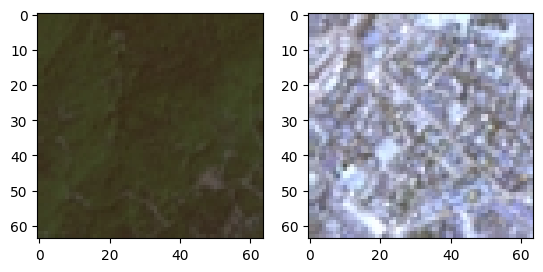

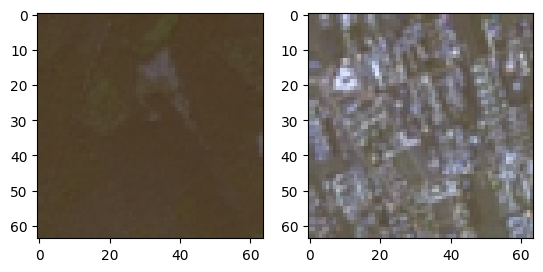

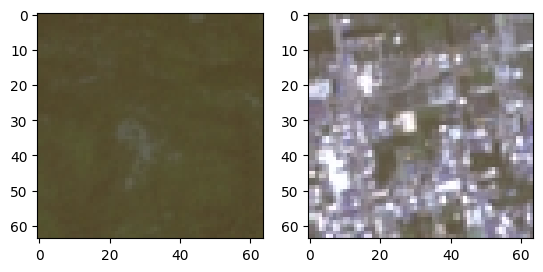

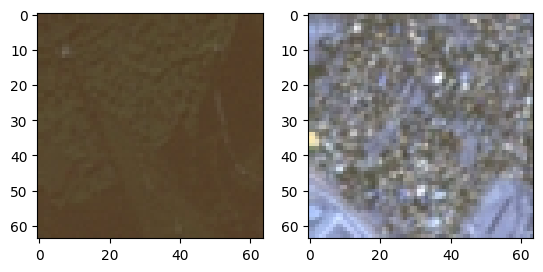

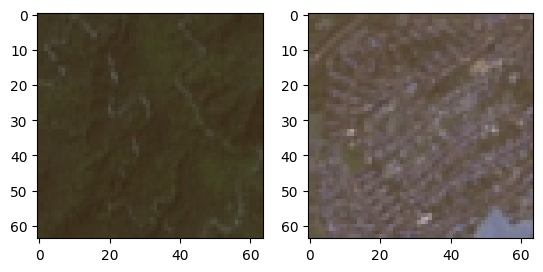

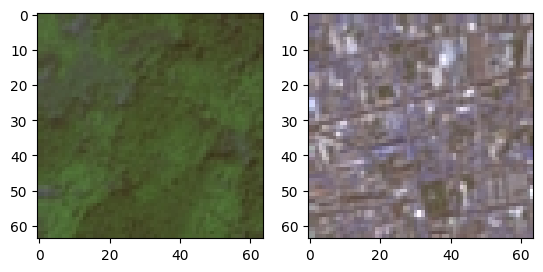

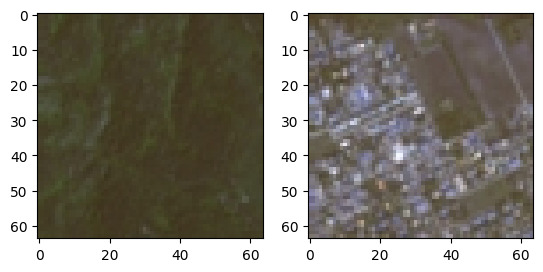

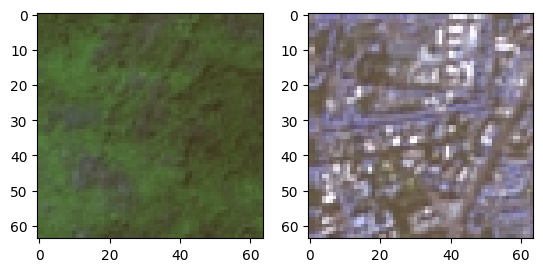

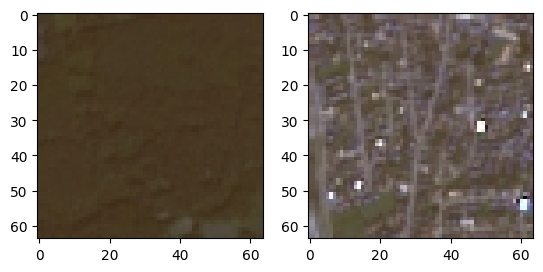

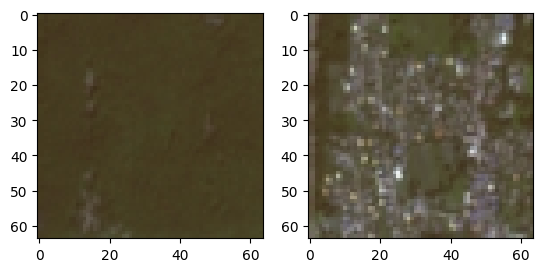

In [ ]:
#To be very sure of our dataset, let's visualize the dataset to see we have the actual images we are looking for

for i in zip(range(10)):
    plt.subplot(1,2,1); plt.imshow(forest[i])
    plt.subplot(1,2,2); plt.imshow(deforest[i])
    plt.show()



Having Generated, Loaded and Preprocessed our data,
we can now proceed to building the Computer Vision Model.

A Computer Vision Model teaches computer how to see and tell diffferences between  images.
In our context, the computer would be given two images and it would tell us if there has been deforestation
between both by spotting differences in the vegetation cover.

We will be using a Convolutional Neural Network (CNN)

CNNs are a form of neural networks that create many folds of images to enable the computer to learn how images
are identified apart from others. It entails a series of convolutions.

### Build The Model Using A Siamese CNN Architecture

In [ ]:

def build_siamese_model():
    # shared feature Extractor (The spatial encoder)
    # The architecture below learns and extract features from images passed to it.
    # This is how the computer learns
    encoder = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
    ], name="Spatial_Encoder")

    # Two inputs are given to the image
    input_before = Input(shape=(64,64,3), name="before_image")
    input_after = Input(shape=(64,64,3), name="after_image")

    # Pass both through the SAME encoder
    features_before = encoder(input_before)
    features_after = encoder(input_after)

    # Compare difference between layers
    # L1 distance
    distance = Lambda(
        lambda tensors:
          tf.abs(tensors[0] - tensors[1]))([features_before, features_after])

    # Classification Head
    outputs = Dense(1, activation='sigmoid')(distance)

    return Model(
        inputs=[input_before, input_after], outputs=outputs
    )

In [ ]:
model = build_siamese_model()

/home/eugene/pipenv/myvenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Split the dataset into training, validation and testing sets

In [ ]:
# The order must be Train, Val, Train, Val...
X_train_forest, X_val_forest, X_train_deforest, X_val_deforest, y_train, y_val = train_test_split(
    forest,
    deforest,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [ ]:
# Check the number of training and validation sets we have
print(f"Training: {len(y_train)}")
print(f"Validation: {len(y_val)}")

Training: 1200
Validation: 300


### Model Compilation (Defines How the Model should learn)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
data_dir = "EuroSAT_RGB/EuroSAT_RGB"
img_size = (64, 64)

In [ ]:

batch_size = 32
epochs = 10

### Model Training (Where The Model Starts Learning)

In [ ]:
print("Start training.........")

history = model.fit(
    [X_train_forest, X_train_deforest], y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=([X_val_forest, X_val_deforest], y_val),
    verbose=1
)

Start training.........
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9025 - loss: 0.3291 - val_accuracy: 0.6667 - val_loss: 0.5718
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9833 - loss: 0.1128 - val_accuracy: 0.6667 - val_loss: 0.5081
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9900 - loss: 0.0628 - val_accuracy: 0.7633 - val_loss: 0.4450
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9933 - loss: 0.0427 - val_accuracy: 0.8467 - val_loss: 0.4785
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9958 - loss: 0.0267 - val_accuracy: 0.7033 - val_loss: 0.5502
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9933 - loss: 0.0286 - val_accuracy: 0.6100 - val_loss: 0.7344
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9958 - loss: 0.0216 - val_accuracy: 0.9033 - val_loss: 0.3058
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9958 - loss: 0.0189 - 

### Evaluation of The Model

In [ ]:
results = model.evaluate([X_val_forest, X_val_deforest], y_val)
results

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7900 - loss: 0.4354


[0.4353667199611664, 0.7900000214576721]

### Generating A Classification Report

In [ ]:
y_pred = model.predict([X_val_forest, X_val_deforest])
y_pred_classes = (y_pred > 0.5).astype(int)

# Print detailed report
print(classification_report(y_val, y_pred_classes))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
              precision    recall  f1-score   support

           0       0.64      0.86      0.73       100
           1       0.92      0.76      0.83       200

    accuracy                           0.79       300
   macro avg       0.78      0.81      0.78       300
weighted avg       0.82      0.79      0.80       300



### Generating The Test Dataset

In [ ]:
# generating time pairs of datasets
def load_and_create_test_pairs(data_dir):
    """
    Manually create pairs from EUROSAT folders.
    Label 1: Deforestation (Forest -> Non-Forest)
    Label 0: No Change (Forest -> Forest)
    """
    forest_path = os.path.join(data_dir, "Forest")
    non_forest_path = os.path.join(data_dir, "Residential")

    # We pick 1000 images from each set
    forest_images = [os.path.join(forest_path, f) for f in os.listdir(forest_path)[1000:2000]]
    non_forest_images = [os.path.join(non_forest_path, f) for f in os.listdir(non_forest_path)[1000:2000]]

    pairs_t1 = []
    pairs_t2 = []
    labels = []

    # Create 'Deforestation' pairs (Forest + residential)
    for i in range(len(non_forest_images)):
        img1 = cv2.imread(forest_images[i])
        img2 = cv2.imread(non_forest_images[i])
        pairs_t1.append(cv2.resize(img1, img_size))
        pairs_t2.append(cv2.resize(img2, img_size))
        labels.append(1)

    # create 'Stable pairs (Forest + Forest)
    for i in range(0, len(forest_images) - 1, 2):
        img1 = cv2.imread(forest_images[i])
        img2 = cv2.imread(forest_images[i+1])
        pairs_t1.append(cv2.resize(img1, img_size))
        pairs_t2.append(cv2.resize(img2, img_size))
        labels.append(0)

    return (
        np.array(pairs_t1)/255.0,
        np.array(pairs_t2)/255.0,
    )

In [ ]:
image_before, image_after = load_and_create_test_pairs(data_dir)

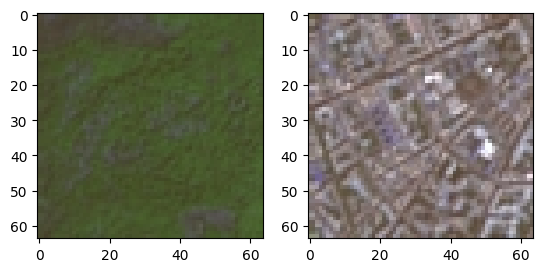

In [ ]:
plt.subplot(1,2,1); plt.imshow(image_before[110])
plt.subplot(1,2,2); plt.imshow(image_after[10])
plt.show()

### Pass The Model To Unseen Data For Classification

In [ ]:
def predict_change(model, img_before, img_after):
    """
    Predicts change between two images.
    img_before/after should be (64, 64, 3) and normalized (0-1).
    """
    # 1. Ensure images have a batch dimension: (1, 64, 64, 3)
    if len(img_before.shape) == 3:
        img_before = np.expand_dims(img_before, axis=0)
    if len(img_after.shape) == 3:
        img_after = np.expand_dims(img_after, axis=0)

    # 2. Convert to float32 (Keras requirement for many backends)
    img_before = img_before.astype('float32')
    img_after = img_after.astype('float32')

    # 3. Predict - wrapping in a list is essential for Siamese models
    try:
        prediction = model.predict([img_before, img_after])
        # 3. Interpretation
        score = float(prediction[0][0])
        is_deforested = score > 0.5
        confidence = score if is_deforested else 1 - score

        if is_deforested:
            return (
               "There's been deforestation between the before and after image",
               f"With prediction confidence of {confidence:.4f} and prediction probability is {score}"
            )
        else:
            return (
               "There's not been deforestation between the before and after image",
               f"With prediction confidence of {confidence:.4f} and prediction probability is {score}"
            )
    except Exception as e:
        # If model.predict fails with TensorShape errors,
        # try model.predict_on_batch which is often more robust for single samples
        prediction = model.predict_on_batch([img_before, img_after])
        # 3. Interpretation
        score = float(prediction[0][0])
        is_deforested = score > 0.5
        confidence = score if is_deforested else 1 - score

        if is_deforested:
            return (
               "There's been deforestation between the before and after image",
               f"With prediction confidence of {confidence:.4f} and prediction probability is {score}"
            )
        else:
            return (
               "There's not been deforestation between the before and after image",
               f"With prediction confidence of {confidence:.4f} and prediction probability is {score}"
            )



In [ ]:
# Execution
predict_change(model, image_before[110], image_after[10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


("There's been deforestation between the before and after image",
 'With prediction confidence of 0.9995 and prediction probability is 0.9995283484458923')